# 🚔 LAPD Crime Intelligence — Notebook 2: Hotspot Prediction Model
**Model:** LightGBM Regression  
**Target:** Crime COUNT per (area, month)  
**Split:** Train = 2020–2023 | Test = 2024–2025  
**CV:** TimeSeriesSplit (no future leakage) + full metric suite

In [1]:
import warnings, joblib
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error, explained_variance_score
)

warnings.filterwarnings('ignore')
plt.style.use('dark_background')

BASE_DIR   = Path('.').resolve()
DATA_DIR   = BASE_DIR / 'data'
MODEL_DIR  = BASE_DIR / 'models';  MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR = BASE_DIR / 'outputs'; OUTPUT_DIR.mkdir(exist_ok=True)

TRAIN_YEARS = [2020, 2021, 2022, 2023]
TEST_YEARS  = [2024, 2025]
GRANULARITY = 'month'   # or 'week'

# GPU detection
try:
    import cupy as cp
    LGBM_DEVICE = 'gpu'
    print('✅ GPU detected — LightGBM GPU mode')
except ImportError:
    LGBM_DEVICE = 'cpu'
    print('⚠️  No RAPIDS — LightGBM CPU mode')

d:\Coding Stuff\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⚠️  No RAPIDS — LightGBM CPU mode


## 1️⃣ Load & Verify Split

In [2]:
df       = pd.read_parquet(DATA_DIR / 'clean_crime.parquet')
df_train = pd.read_parquet(DATA_DIR / 'train_crime.parquet')
df_test  = pd.read_parquet(DATA_DIR / 'test_crime.parquet')

print(f'Train: {len(df_train):,} rows | years: {sorted(df_train["year"].unique())}')
print(f'Test : {len(df_test):,} rows  | years: {sorted(df_test["year"].unique())}')

Train: 875,087 rows | years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Test : 127,664 rows  | years: [np.int64(2024), np.int64(2025)]


## 2️⃣ Build Aggregated Count Features (area + month level)

In [3]:
def build_count_agg(source_df, granularity='month'):
    time_col = 'month' if granularity == 'month' else 'week'
    group    = ['area', 'year', time_col]

    has_cat = 'crime_category' in source_df.columns
    has_wkd = 'is_weekend'     in source_df.columns

    agg_dict = {'crime_count': ('crm_cd', 'count'),
                'unique_crimes': ('crm_cd', 'nunique'),
                'avg_hour': ('hour', 'mean'),
                'night_crimes': ('hour', lambda x: ((x >= 20) | (x <= 5)).sum())}
    if has_cat:
        agg_dict['violent_crimes']  = ('crime_category', lambda x: (x == 'Aggravated Assault').sum())
        agg_dict['property_crimes'] = ('crime_category', lambda x: x.isin(['Theft/Larceny','Vehicle Theft','Burglary']).sum())
    if has_wkd:
        agg_dict['weekend_crimes'] = ('is_weekend', 'sum')

    agg = source_df.groupby(group).agg(**agg_dict).reset_index()
    agg = agg.sort_values(['area', 'year', time_col]).reset_index(drop=True)
    return agg


def add_lag_features(agg, granularity='month'):
    time_col = 'month' if granularity == 'month' else 'week'

    # Lag features (1–6 periods back)
    for lag in [1, 2, 3, 6]:
        agg[f'crime_lag_{lag}'] = agg.groupby('area')['crime_count'].shift(lag)

    # Rolling mean and std
    for w in [3, 6]:
        agg[f'crime_roll_mean_{w}'] = agg.groupby('area')['crime_count'].transform(
            lambda x: x.shift(1).rolling(w, min_periods=1).mean())
        agg[f'crime_roll_std_{w}'] = agg.groupby('area')['crime_count'].transform(
            lambda x: x.shift(1).rolling(w, min_periods=1).std().fillna(0))

    # Year-over-year lag
    periods_per_year = 12 if granularity == 'month' else 52
    agg['crime_yoy_lag'] = agg.groupby('area')['crime_count'].shift(periods_per_year)

    # Cyclical encoding
    max_p = 12 if granularity == 'month' else 52
    agg[f'{time_col}_sin'] = np.sin(2 * np.pi * agg[time_col] / max_p)
    agg[f'{time_col}_cos'] = np.cos(2 * np.pi * agg[time_col] / max_p)

    # Area historical avg
    area_avg = (agg.groupby('area')['crime_count'].mean().rename('area_avg_crimes')).reset_index()
    agg = agg.merge(area_avg, on='area', how='left')
    return agg


# Build on FULL data (lags require history before 2024 to predict 2024)
print('Building aggregate features on full dataset...')
agg_full = build_count_agg(df, GRANULARITY)
agg_full = add_lag_features(agg_full, GRANULARITY)

# Split by year AFTER lag computation (no leakage — lags only look backward)
agg_train = agg_full[agg_full['year'].isin(TRAIN_YEARS)].dropna(subset=['crime_lag_1','crime_lag_2']).reset_index(drop=True)
agg_test  = agg_full[agg_full['year'].isin(TEST_YEARS)].dropna(subset=['crime_lag_1','crime_lag_2']).reset_index(drop=True)

print(f'Agg train: {len(agg_train):,} rows | Agg test: {len(agg_test):,} rows')
agg_train.head(3)

Building aggregate features on full dataset...
Agg train: 966 rows | Agg test: 294 rows


,area,year,month,crime_count,unique_crimes,avg_hour,night_crimes,violent_crimes,property_crimes,weekend_crimes,...,crime_lag_3,crime_lag_6,crime_roll_mean_3,crime_roll_std_3,crime_roll_mean_6,crime_roll_std_6,crime_yoy_lag,month_sin,month_cos,area_avg_crimes
0,1,2020,3,967,61,12.955533,323,151,333,285,...,NaN,NaN,1170.000000,60.811183,1170.000000,60.811183,NaN,1.000000,6.123234e-17,1120.580645
1,1,2020,4,796,55,12.520101,259,88,291,197,...,1213.0,NaN,1102.333333,124.841233,1102.333333,124.841233,NaN,0.866025,-5.000000e-01,1120.580645
2,1,2020,5,1063,58,13.483537,436,103,414,343,...,1127.0,NaN,963.333333,165.530460,1025.750000,183.984374,NaN,0.500000,-8.660254e-01,1120.580645


In [4]:
FEATURE_COLS = [
    'area', 'year', GRANULARITY,
    f'{GRANULARITY}_sin', f'{GRANULARITY}_cos',
    'crime_lag_1', 'crime_lag_2', 'crime_lag_3', 'crime_lag_6',
    'crime_roll_mean_3', 'crime_roll_mean_6',
    'crime_roll_std_3',  'crime_roll_std_6',
    'crime_yoy_lag', 'unique_crimes', 'avg_hour', 'night_crimes',
    'area_avg_crimes',
]
# Add optional cols if they exist
for opt in ['violent_crimes','property_crimes','weekend_crimes']:
    if opt in agg_train.columns: FEATURE_COLS.append(opt)
FEATURE_COLS = [c for c in FEATURE_COLS if c in agg_train.columns]

X_train = agg_train[FEATURE_COLS].fillna(0).astype(float)  # float64 — no Int issues
y_train = agg_train['crime_count'].astype(float).values
X_test  = agg_test[FEATURE_COLS].fillna(0).astype(float)
y_test  = agg_test['crime_count'].astype(float).values

print(f'X_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')
print(f'y_train dtype: {y_train.dtype} (must be float64)')

X_train shape: (966, 21)
X_test  shape: (294, 21)
y_train dtype: float64 (must be float64)


## 3️⃣ TimeSeriesSplit CV on Training Data

In [6]:
PARAMS = {
    'objective':        'regression',
    'metric':           ['mae','rmse'],
    'boosting_type':    'gbdt',
    'n_estimators':     1000,
    'learning_rate':    0.05,
    'num_leaves':       63,
    'max_depth':        7,
    'min_child_samples':5,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'reg_alpha':        0.1,
    'reg_lambda':       0.1,
    'verbose':          -1,
    'device':           LGBM_DEVICE,
    'random_state':     42,
    'n_jobs':           -1,
}
if LGBM_DEVICE == 'gpu':
    PARAMS.update({'gpu_platform_id': 0, 'gpu_device_id': 0})

N_SPLITS   = 4
tscv       = TimeSeriesSplit(n_splits=N_SPLITS)
cv_records = []
best_iters = []
oof_preds  = np.zeros(len(X_train))   # out-of-fold predictions

print(f'Running {N_SPLITS}-fold TimeSeriesSplit CV...')
print(f'Each fold trains on past, validates on future (no leakage)\n')

fold_bar = tqdm(enumerate(tscv.split(X_train)), total=N_SPLITS, desc='CV Folds')

for fold, (tr_idx, val_idx) in fold_bar:
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[tr_idx],      y_train[val_idx]

    model = lgb.LGBMRegressor(**PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )
    preds = model.predict(X_val)
    oof_preds[val_idx] = preds

    mae   = mean_absolute_error(y_val, preds)
    rmse  = np.sqrt(mean_squared_error(y_val, preds))
    mape  = mean_absolute_percentage_error(y_val, preds) * 100
    r2    = r2_score(y_val, preds)
    evs   = explained_variance_score(y_val, preds)

    cv_records.append({'Fold': fold+1, 'MAE': mae, 'RMSE': rmse,
                       'MAPE%': mape, 'R2': r2, 'ExplVar': evs,
                       'Best_iter': model.best_iteration_})
    best_iters.append(model.best_iteration_)
    fold_bar.set_postfix(MAE=f'{mae:.1f}', R2=f'{r2:.3f}')

cv_df = pd.DataFrame(cv_records)
print('\n' + '='*65)
print('  CROSS-VALIDATION RESULTS (TimeSeriesSplit)')
print('='*65)
print(cv_df.to_string(index=False))
print('─'*65)
print(f'  Mean MAE    : {cv_df["MAE"].mean():.2f} ± {cv_df["MAE"].std():.2f}')
print(f'  Mean RMSE   : {cv_df["RMSE"].mean():.2f} ± {cv_df["RMSE"].std():.2f}')
print(f'  Mean MAPE   : {cv_df["MAPE%"].mean():.1f}% ± {cv_df["MAPE%"].std():.1f}%')
print(f'  Mean R2     : {cv_df["R2"].mean():.4f} ± {cv_df["R2"].std():.4f}')
print(f'  Mean ExplVar: {cv_df["ExplVar"].mean():.4f}')
print('='*65)

cv_df.to_csv(OUTPUT_DIR / 'cv_metrics_hotspot.csv', index=False)

Running 4-fold TimeSeriesSplit CV...
Each fold trains on past, validates on future (no leakage)



CV Folds: 100%|██████████| 4/4 [00:00<00:00, 10.89it/s, MAE=31.3, R2=0.887]


  CROSS-VALIDATION RESULTS (TimeSeriesSplit)
 Fold       MAE      RMSE    MAPE%       R2  ExplVar  Best_iter
    1 40.479412 51.860604 4.817828 0.809663 0.811304         33
    2 33.473445 42.473600 3.979830 0.939417 0.940610         77
    3 31.226383 39.500195 3.865489 0.958462 0.959726        198
    4 31.348218 40.918513 3.853403 0.887295 0.900011         84
─────────────────────────────────────────────────────────────────
  Mean MAE    : 34.13 ± 4.36
  Mean RMSE   : 43.69 ± 5.58
  Mean MAPE   : 4.1% ± 0.5%
  Mean R2     : 0.8987 ± 0.0666
  Mean ExplVar: 0.9029


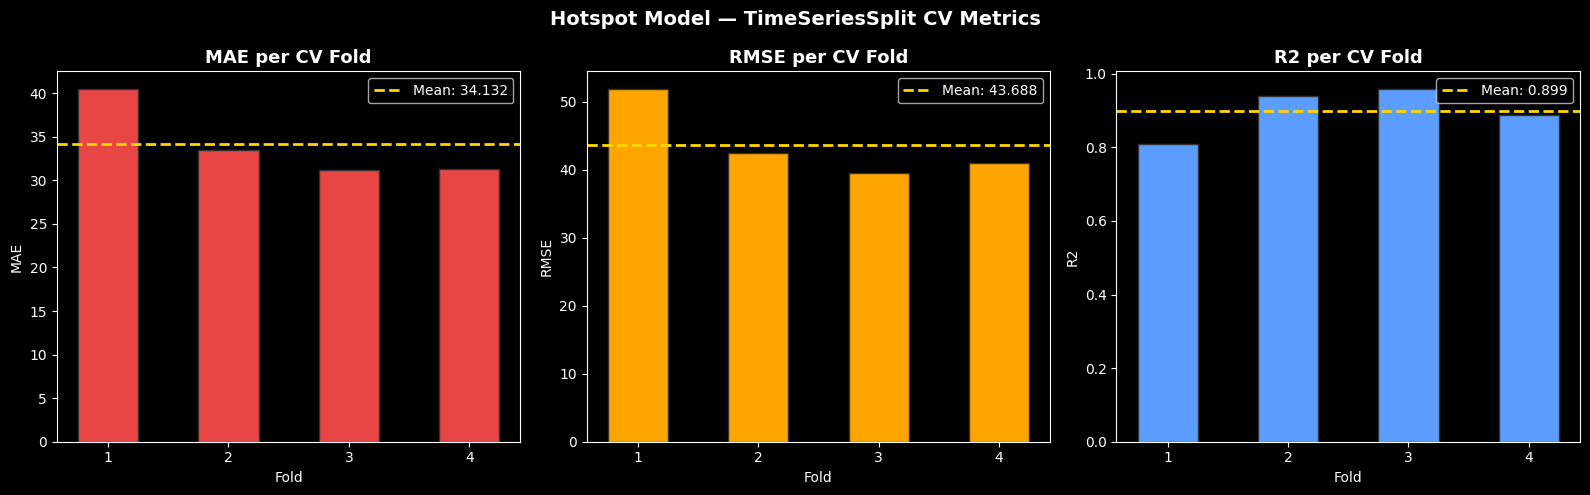

In [7]:
# ── CV metrics visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors  = ['#E84545', '#FFA500', '#5C9EFF']

for ax, metric, color in zip(axes, metrics, colors):
    ax.bar(cv_df['Fold'].astype(str), cv_df[metric], color=color, width=0.5, edgecolor='#333')
    ax.axhline(cv_df[metric].mean(), color='gold', linestyle='--', linewidth=2,
               label=f'Mean: {cv_df[metric].mean():.3f}')
    ax.set_title(f'{metric} per CV Fold', fontsize=13, fontweight='bold')
    ax.set_xlabel('Fold'); ax.set_ylabel(metric)
    ax.legend()

plt.suptitle('Hotspot Model — TimeSeriesSplit CV Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_metrics_hotspot.png', dpi=150)
plt.show()

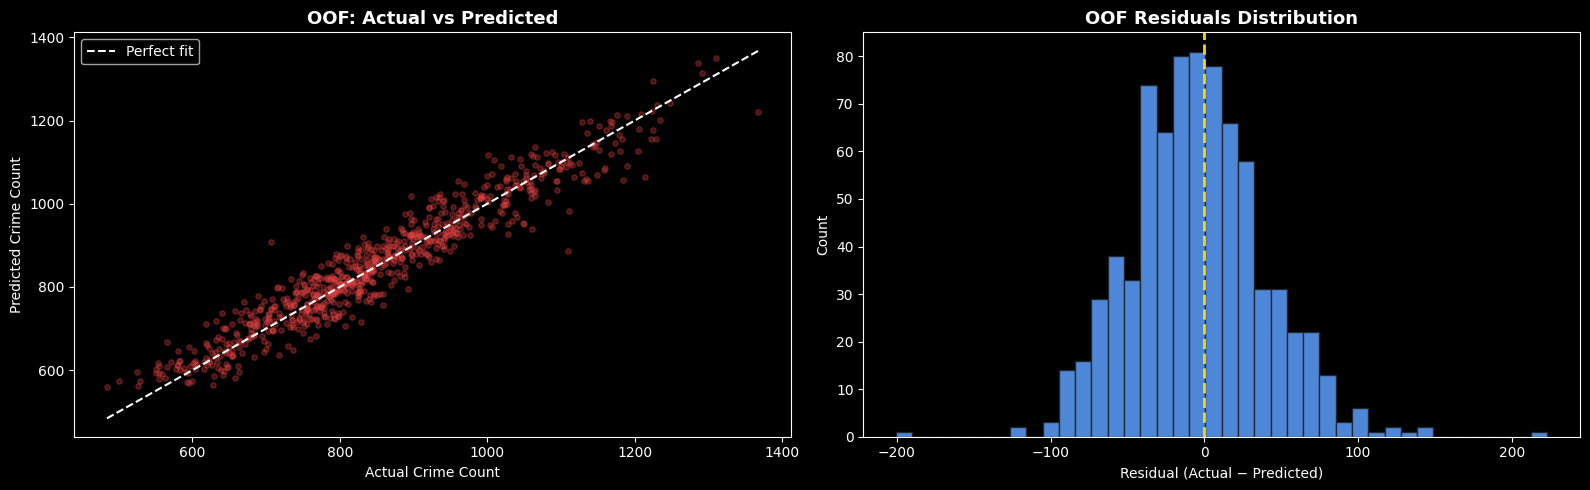

In [8]:
# ── OOF predictions vs actual ─────────────────────────────────────────────
oof_mask = oof_preds != 0  # zero where not predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter: actual vs predicted
axes[0].scatter(y_train[oof_mask], oof_preds[oof_mask],
                alpha=0.3, color='#E84545', s=15)
mn = min(y_train[oof_mask].min(), oof_preds[oof_mask].min())
mx = max(y_train[oof_mask].max(), oof_preds[oof_mask].max())
axes[0].plot([mn, mx], [mn, mx], 'w--', linewidth=1.5, label='Perfect fit')
axes[0].set_title('OOF: Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Crime Count')
axes[0].set_ylabel('Predicted Crime Count')
axes[0].legend()

# Residuals
residuals = y_train[oof_mask] - oof_preds[oof_mask]
axes[1].hist(residuals, bins=40, color='#5C9EFF', edgecolor='#222', alpha=0.85)
axes[1].axvline(0, color='gold', linestyle='--', linewidth=2)
axes[1].set_title('OOF Residuals Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'oof_diagnostics_hotspot.png', dpi=150)
plt.show()

## 4️⃣ Train Final Model on ALL Training Data

In [9]:
best_n_estimators = int(np.mean(best_iters)) + 50
print(f'Best avg iteration from CV: {int(np.mean(best_iters))}')
print(f'Final n_estimators: {best_n_estimators}')

FINAL_PARAMS = {**PARAMS, 'n_estimators': best_n_estimators}

final_model = lgb.LGBMRegressor(**FINAL_PARAMS)

with tqdm(total=best_n_estimators, desc='Training final model', unit='tree') as pbar:
    class ProgressCB:
        def __call__(self, env): pbar.update(1)
    final_model.fit(X_train, y_train,
                    callbacks=[lgb.log_evaluation(period=-1), ProgressCB()])

print('✅ Final model trained')

Best avg iteration from CV: 98
Final n_estimators: 148


Training final model: 100%|██████████| 148/148 [00:00<00:00, 774.76tree/s]

✅ Final model trained


## 5️⃣ Test Set Evaluation (2024–2025 Holdout)

In [10]:
y_pred_test = final_model.predict(X_test)

test_mae  = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100
test_r2   = r2_score(y_test, y_pred_test)
test_evs  = explained_variance_score(y_test, y_pred_test)

print('='*55)
print('  HOLDOUT TEST SET METRICS  (2024–2025)')
print('='*55)
print(f'  MAE               : {test_mae:.2f} incidents/month')
print(f'  RMSE              : {test_rmse:.2f}')
print(f'  MAPE              : {test_mape:.1f}%')
print(f'  R²                : {test_r2:.4f}')
print(f'  Explained Variance: {test_evs:.4f}')
print('='*55)

test_metrics = pd.DataFrame([{
    'Split': 'Test (2024-25)', 'MAE': test_mae, 'RMSE': test_rmse,
    'MAPE%': test_mape, 'R²': test_r2, 'ExplVar': test_evs
}])
test_metrics.to_csv(OUTPUT_DIR / 'test_metrics_hotspot.csv', index=False)

  HOLDOUT TEST SET METRICS  (2024–2025)
  MAE               : 221.26 incidents/month
  RMSE              : 272.20
  MAPE              : 4981.5%
  R²                : 0.1558
  Explained Variance: 0.6810


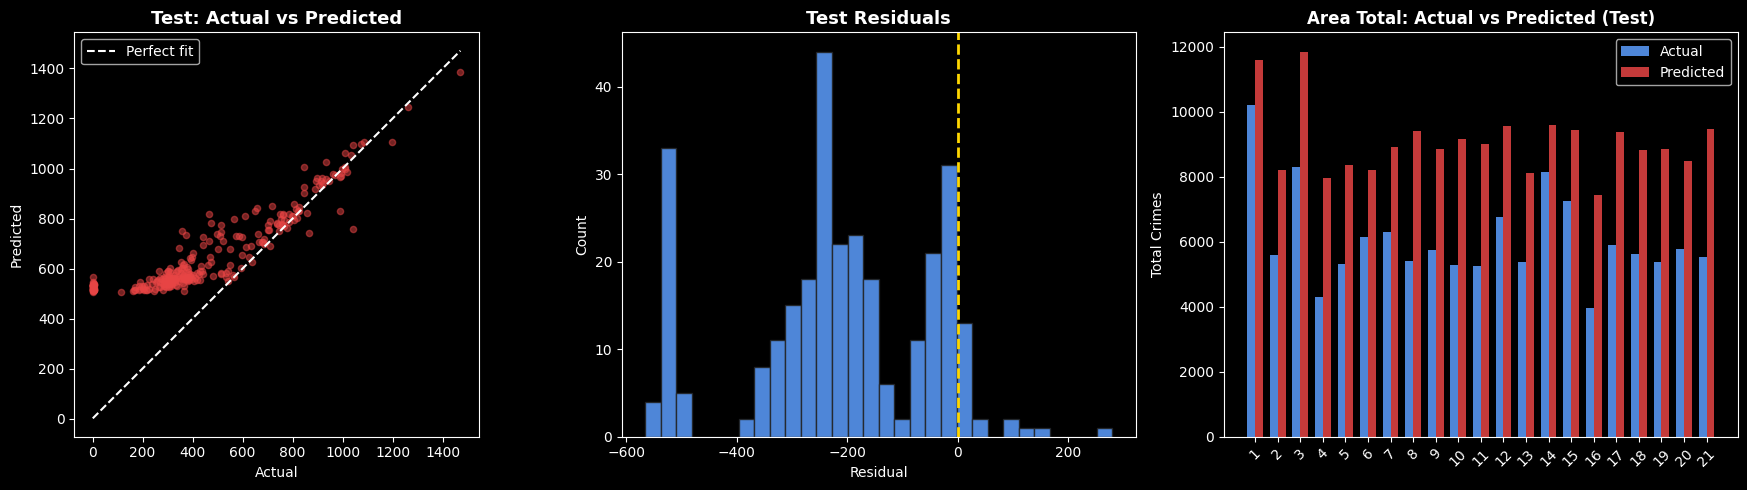

In [11]:
# ── Test set actual vs predicted ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter
axes[0].scatter(y_test, y_pred_test, alpha=0.5, color='#E84545', s=20)
mn, mx = min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())
axes[0].plot([mn,mx],[mn,mx],'w--',linewidth=1.5,label='Perfect fit')
axes[0].set_title('Test: Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_aspect('equal'); axes[0].legend()

# Residuals histogram
res_test = y_test - y_pred_test
axes[1].hist(res_test, bins=30, color='#5C9EFF', edgecolor='#222', alpha=0.85)
axes[1].axvline(0, color='gold', linestyle='--', linewidth=2)
axes[1].set_title('Test Residuals', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')

# Per-area comparison
agg_test_copy = agg_test.copy()
agg_test_copy['predicted'] = y_pred_test
area_compare = agg_test_copy.groupby('area').agg(
    actual=('crime_count','sum'), predicted=('predicted','sum')
).reset_index()
x = np.arange(len(area_compare))
w = 0.35
axes[2].bar(x - w/2, area_compare['actual'],    w, label='Actual',    color='#5C9EFF', alpha=0.85)
axes[2].bar(x + w/2, area_compare['predicted'], w, label='Predicted', color='#E84545', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(area_compare['area'].astype(int).astype(str), rotation=45)
axes[2].set_title('Area Total: Actual vs Predicted (Test)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Total Crimes'); axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'test_evaluation_hotspot.png', dpi=150)
plt.show()

In [13]:
# ── CV vs Test metric comparison table ────────────────────────────────────
summary = pd.DataFrame({
    'Metric'  : ['MAE', 'RMSE', 'MAPE (%)', 'R2', 'Explained Variance'],
    'CV Mean' : [cv_df['MAE'].mean(), cv_df['RMSE'].mean(),
                 cv_df['MAPE%'].mean(), cv_df['R2'].mean(), cv_df['ExplVar'].mean()],
    'CV Std'  : [cv_df['MAE'].std(),  cv_df['RMSE'].std(),
                 cv_df['MAPE%'].std(),cv_df['R2'].std(), cv_df['ExplVar'].std()],
    'Test'    : [test_mae, test_rmse, test_mape, test_r2, test_evs],
})
summary[['CV Mean','CV Std','Test']] = summary[['CV Mean','CV Std','Test']].round(4)
print('\n  FULL METRICS COMPARISON')
print(summary.to_string(index=False))
summary.to_csv(OUTPUT_DIR / 'metrics_summary_hotspot.csv', index=False)


  FULL METRICS COMPARISON
            Metric  CV Mean  CV Std      Test
               MAE  34.1319  4.3557  221.2633
              RMSE  43.6882  5.5819  272.1988
          MAPE (%)   4.1291  0.4626 4981.4824
                R2   0.8987  0.0666    0.1558
Explained Variance   0.9029  0.0660    0.6810


## 6️⃣ Feature Importance + SHAP

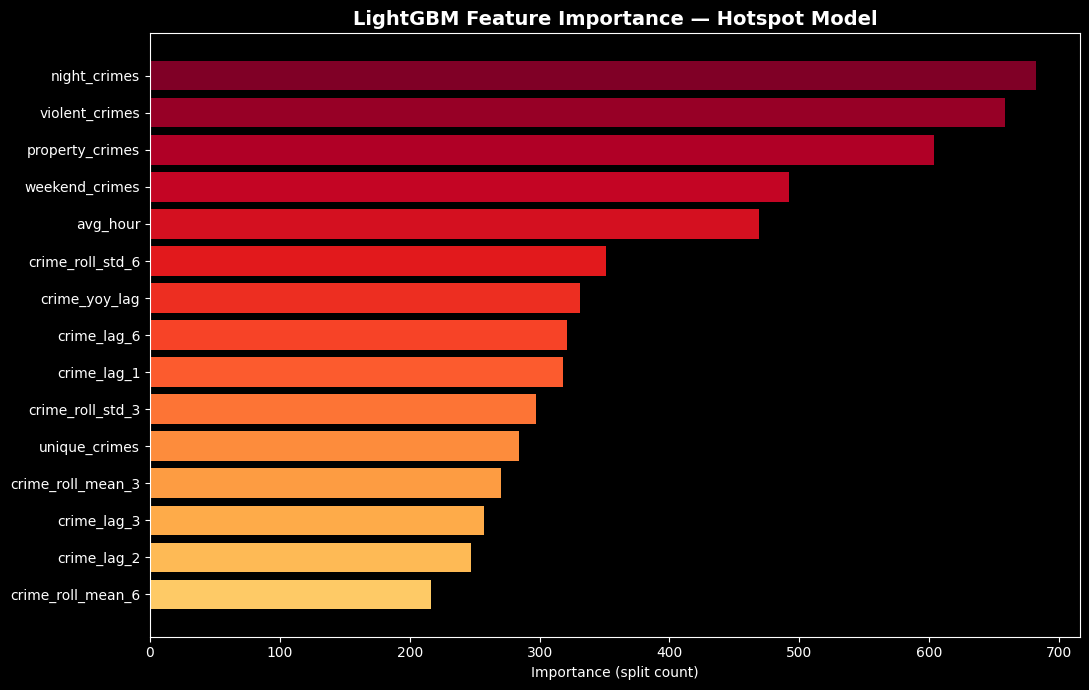

         feature  importance
    night_crimes         682
  violent_crimes         658
 property_crimes         604
  weekend_crimes         492
        avg_hour         469
crime_roll_std_6         351
   crime_yoy_lag         331
     crime_lag_6         321
     crime_lag_1         318
crime_roll_std_3         297


In [14]:
# Feature importance
fi_df = pd.DataFrame({'feature': FEATURE_COLS,
                      'importance': final_model.feature_importances_
                     }).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(11, 7))
top = fi_df.head(15)
colors = plt.cm.YlOrRd(np.linspace(0.3, 1.0, 15))[::-1]
ax.barh(top['feature'][::-1], top['importance'][::-1], color=colors[::-1])
ax.set_title('LightGBM Feature Importance — Hotspot Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance (split count)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance_hotspot.png', dpi=150)
plt.show()
print(fi_df.head(10).to_string(index=False))

Computing SHAP values (sample of 1000 rows)...


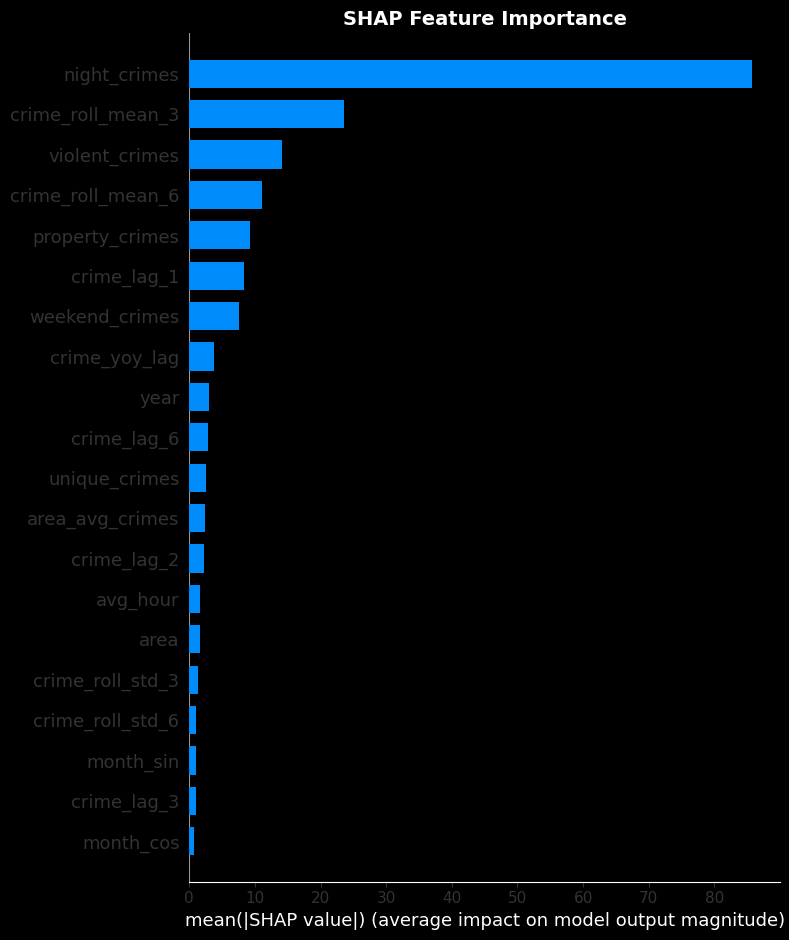

In [15]:
# SHAP values
print('Computing SHAP values (sample of 1000 rows)...')
sample_idx  = np.random.choice(len(X_train), size=min(1000, len(X_train)), replace=False)
X_shap      = X_train.iloc[sample_idx]
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

# Summary bar plot
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False)
plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_summary_hotspot.png', dpi=150, bbox_inches='tight')
plt.show()

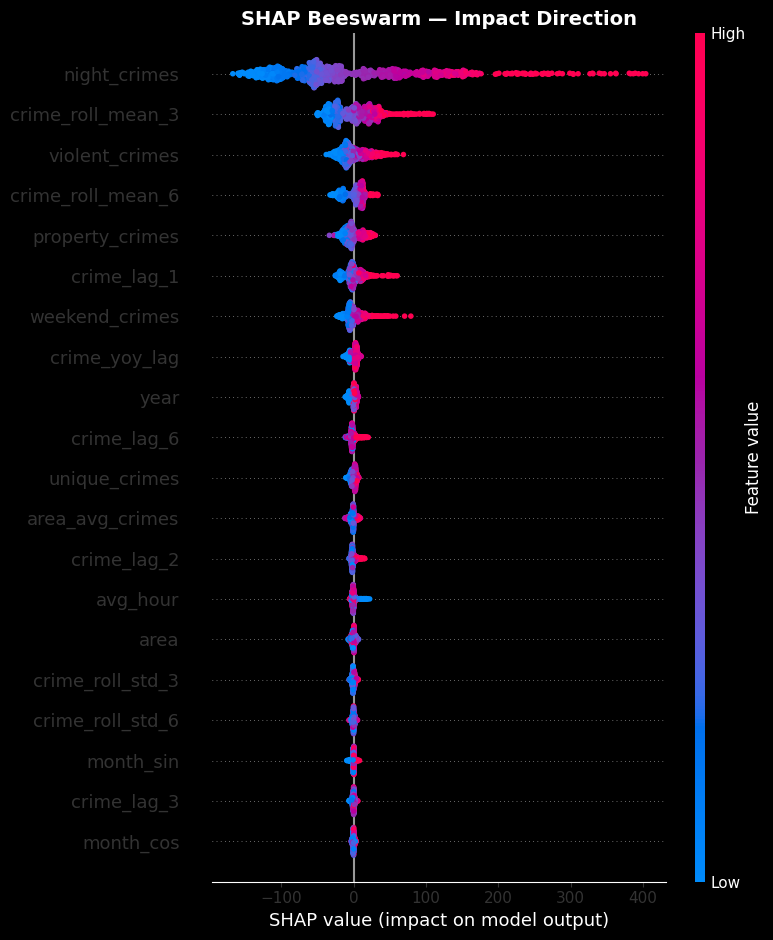

In [16]:
# SHAP beeswarm (shows direction of impact)
fig = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title('SHAP Beeswarm — Impact Direction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_beeswarm_hotspot.png', dpi=150, bbox_inches='tight')
plt.show()

## 7️⃣ Save Model

In [17]:
joblib.dump(final_model,  MODEL_DIR / f'hotspot_model_{GRANULARITY}.pkl')
joblib.dump(FEATURE_COLS, MODEL_DIR / f'hotspot_features_{GRANULARITY}.pkl')
agg_full.to_parquet(DATA_DIR / f'agg_{GRANULARITY}.parquet', index=False)

print(f'✅ Model saved  : {MODEL_DIR / f"hotspot_model_{GRANULARITY}.pkl"}')
print(f'✅ Features saved: {MODEL_DIR / f"hotspot_features_{GRANULARITY}.pkl"}')
print(f'✅ Agg data saved: {DATA_DIR / f"agg_{GRANULARITY}.parquet"}')

# Quick sanity predict
sample_pred = final_model.predict(X_test.head(5))
print(f'\nSample predictions vs actual:')
for pred, actual in zip(sample_pred, y_test[:5]):
    print(f'  Predicted: {pred:.0f}  |  Actual: {actual:.0f}')

✅ Model saved  : D:\Coding Stuff\pps5\models\hotspot_model_month.pkl
✅ Features saved: D:\Coding Stuff\pps5\models\hotspot_features_month.pkl
✅ Agg data saved: D:\Coding Stuff\pps5\data\agg_month.parquet

Sample predictions vs actual:
  Predicted: 1386  |  Actual: 1471
  Predicted: 1248  |  Actual: 1262
  Predicted: 1006  |  Actual: 846
  Predicted: 811  |  Actual: 611
  Predicted: 736  |  Actual: 661
